# Analysis Star Rating - Text Mismatch in Restaurant Reviews

This notebook analyses **star rating–text mismatch** in UK restaurant reviews: we predict star ratings from text (TF-IDF and RoBERTa sentiment), then use RoBERTa zero-shot to flag reviews where the written sentiment disagrees with the star rating. The pipeline is ordered as: **data load & cleaning → EDA → feature engineering (TF-IDF, RoBERTa) → hyperparameter tuning → model training & evaluation → mismatch detection (simple and refined) → error/lexical analysis**. Tuning was added for comparability; the main reported results use the best cross-validated settings.

## Data Cleaning & Prepocessing

In [1]:
# import
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, f1_score, confusion_matrix
from collections import Counter
from transformers import pipeline

In [2]:
# Preprocessing approach adapted from Week 2 (Language Representation)

# Load dataset
df_ori = pd.read_csv("uk_restaurant_reviews.csv")

# Initial data inspection
df_ori.info()                 # Check data types and non-null counts
df_ori.head()                 # Preview first few rows
df_ori.describe()             # Summary statistics (numeric columns)
df_ori['review_rating'].value_counts()  # Distribution of ratings
df_ori.isnull().sum()         # Count missing values per column

print("\nMissing values:\n", df_ori.isnull().sum())

# Create a working copy to preserve original data
df = df_ori.copy()

# =========================
# Data Cleaning
# =========================

# Remove rows with missing text or rating
df = df.dropna(subset=['review_text', 'review_rating'])

# Remove empty or whitespace-only reviews
df = df[df['review_text'].str.strip() != ""]

# Ensure ratings are numeric (invalid values → NaN)
df['review_rating'] = pd.to_numeric(df['review_rating'], errors='coerce')

# Keep only valid ratings between 1 and 5
df = df[df['review_rating'].between(1, 5)]

# Remove duplicate reviews (same text and rating)
df = df.drop_duplicates(subset=['review_text', 'review_rating'])

# Convert UNIX timestamp to datetime
df['review_date'] = pd.to_datetime(df['review_time'], unit='s')

# Extract useful temporal features
df['year'] = df['review_date'].dt.year
df['month'] = df['review_date'].dt.month

# Create review length features
df['review_length_words'] = df['review_text'].apply(lambda x: len(str(x).split()))
df['review_length_chars'] = df['review_text'].apply(lambda x: len(str(x)))

# Drop unnecessary column
df = df.drop(columns=['author_name'])

# Post-cleaning checks
print("\nAfter cleaning:", len(df))
print("\nMissing values:\n", df.isnull().sum())
print("\nRating distribution:\n", df['review_rating'].value_counts())


# =========================
# Text Preprocessing
# =========================

# Download required NLTK resources (only runs if not already installed)
nltk.download('stopwords')
nltk.download('wordnet')

# Define stopwords (keep negations as they are important for sentiment)
stop_words = set(stopwords.words('english')) - {'not', 'no', 'never'}

# Initialize lemmatizer
lemmatizer = WordNetLemmatizer()


def preprocess_text(text):
    """
    Clean and normalise review text:
    - Lowercase
    - Remove punctuation and numbers
    - Remove extra whitespace
    - Remove stopwords (except negations)
    - Apply lemmatization
    """
    text = str(text).lower()

    # Remove punctuation and numbers
    text = re.sub(r"[^a-z\s]", "", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    # Remove stopwords (retain negation words)
    words = [w for w in text.split() if w not in stop_words]

    # Lemmatise words (reduce to base form)
    words = [lemmatizer.lemmatize(w) for w in words]

    return " ".join(words)


# Apply preprocessing to all reviews
df['clean_text'] = df['review_text'].apply(preprocess_text)

print("\nPreprocessing complete")

# Preview cleaned data
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6150 entries, 0 to 6149
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   place_id                   6150 non-null   object
 1   place_name                 6150 non-null   object
 2   review_rating              6150 non-null   int64 
 3   review_text                6116 non-null   object
 4   review_language            6116 non-null   object
 5   review_time                6150 non-null   int64 
 6   relative_time_description  6150 non-null   object
 7   author_name                6150 non-null   object
dtypes: int64(2), object(6)
memory usage: 384.5+ KB

Missing values:
 place_id                      0
place_name                    0
review_rating                 0
review_text                  34
review_language              34
review_time                   0
relative_time_description     0
author_name                   0
dtype: int64

Afte

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...



Preprocessing complete


,place_id,place_name,review_rating,review_text,review_language,review_time,relative_time_description,review_date,year,month,review_length_words,review_length_chars,clean_text
0,ChIJm9UXZ94JdkgRwy2rlAHW-Vs,Costa Coffee,5,What a wonderful experience in Costa coffee Wi...,en,1764429424,2 months ago,2025-11-29 15:17:04,2025,11,137,840,wonderful experience costa coffee wimbledon st...
1,ChIJm9UXZ94JdkgRwy2rlAHW-Vs,Costa Coffee,4,"Usually service is slow compared to Nero's, no...",en,1745485215,9 months ago,2025-04-24 09:00:15,2025,4,42,239,usually service slow compared nero not good yo...
2,ChIJm9UXZ94JdkgRwy2rlAHW-Vs,Costa Coffee,5,Had a fantastic experience this morning. Fabu...,en,1767613105,a month ago,2026-01-05 11:38:25,2026,1,26,158,fantastic experience morning fabulous service ...
3,ChIJm9UXZ94JdkgRwy2rlAHW-Vs,Costa Coffee,1,Rude staff forgot to make my tea as they was b...,en,1766495604,a month ago,2025-12-23 13:13:24,2025,12,67,344,rude staff forgot make tea busy understand mis...
4,ChIJm9UXZ94JdkgRwy2rlAHW-Vs,Costa Coffee,5,"Really lovely service with a smile, and really...",en,1659109614,3 years ago,2022-07-29 15:46:54,2022,7,85,497,really lovely service smile really genuinely h...


## EDA

### 1. Dataset Overview

In [3]:
# =========================
# Final Dataset Overview
# =========================

# Print final dataset shape (rows, columns)
print("Final shape:", df.shape)

# List all column names after cleaning and feature engineering
print("\nColumns:", df.columns.tolist())

# =========================
# Summary Statistics
# =========================

# Summary statistics for review ratings (mean, std, min, max, quartiles)
print("\nRating summary:")
print(df['review_rating'].describe())

# Summary statistics for review length (in words)
print("\nReview length (words) summary:")
print(df['review_length_words'].describe())

Final shape: (6113, 13)

Columns: ['place_id', 'place_name', 'review_rating', 'review_text', 'review_language', 'review_time', 'relative_time_description', 'review_date', 'year', 'month', 'review_length_words', 'review_length_chars', 'clean_text']

Rating summary:
count    6113.000000
mean        3.037298
std         1.792833
min         1.000000
25%         1.000000
50%         3.000000
75%         5.000000
max         5.000000
Name: review_rating, dtype: float64

Review length (words) summary:
count    6113.000000
mean       67.805169
std        55.692030
min         1.000000
25%        33.000000
50%        53.000000
75%        84.000000
max       752.000000
Name: review_length_words, dtype: float64


### 2. Target Variable Analysis (Review Rating)
#### Distribution

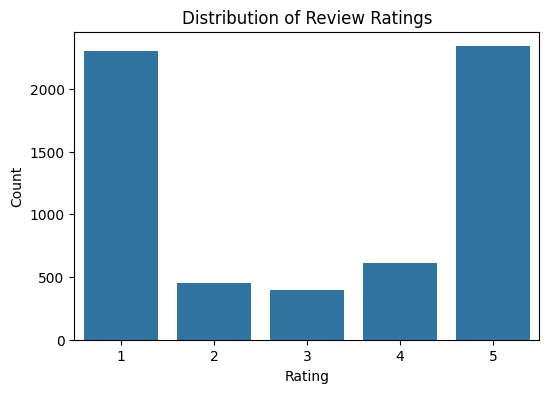

In [4]:
# =========================
# Rating Distribution Plot
# =========================

# Create figure with specified size
plt.figure(figsize=(6,4))

# Plot count of each rating (1–5)
sns.countplot(x='review_rating', data=df)

# Add title and axis labels
plt.title("Distribution of Review Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")

# Display the plot
plt.show()

#### Percentage Distribution

In [5]:
# =========================
# Rating Percentage Distribution
# =========================

# Sort ratings and round to 2 decimal places
rating_percent = df['review_rating'].value_counts(normalize=True).sort_index() * 100
print(rating_percent.round(2))

review_rating
1    37.74
2     7.39
3     6.54
4    10.04
5    38.28
Name: proportion, dtype: float64


### 3. Review Length Analysis
#### Distribution of review length

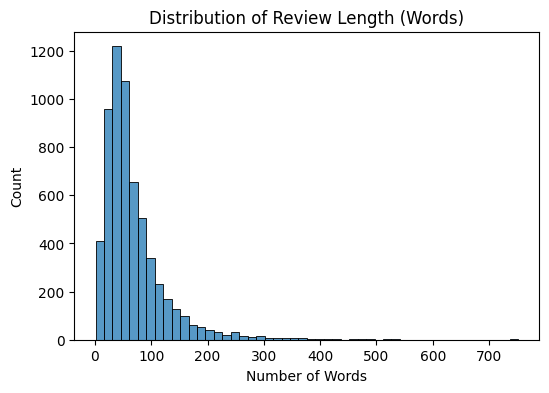

In [6]:
# =========================
# Review Length Distribution (Words)
# =========================

# Create figure with specified size
plt.figure(figsize=(6,4))

# Plot histogram of review lengths (in words)
sns.histplot(df['review_length_words'], bins=50)

# Add title and axis labels
plt.title("Distribution of Review Length (Words)")
plt.xlabel("Number of Words")

# Display the plot
plt.show()

#### Compare length by rating

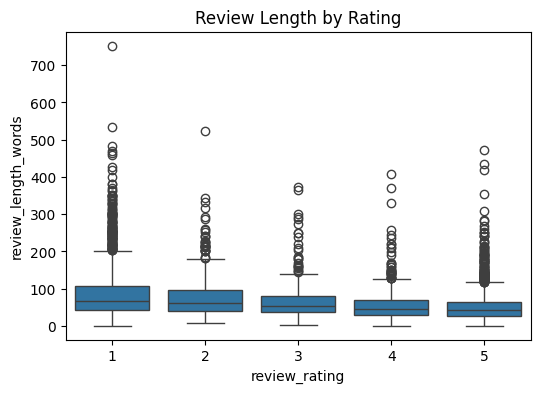

In [7]:
# =========================
# Review Length by Rating (Boxplot)
# =========================

# Create figure with specified size
plt.figure(figsize=(6,4))

# Ensure ratings appear in sorted order
sns.boxplot(
    x='review_rating',
    y='review_length_words',
    data=df,
    order=sorted(df['review_rating'].unique())
)

# Add title
plt.title("Review Length by Rating")

# Display the plot
plt.show()

### 4. Time-Based Analysis
#### Reviews over time

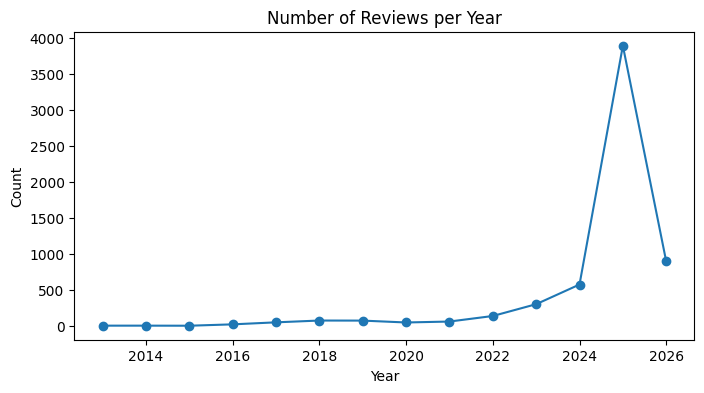

In [8]:
# =========================
# Reviews per Year (Time Trend)
# =========================

# Count number of reviews per year and sort chronologically
reviews_per_year = df['year'].value_counts().sort_index()

# Create figure with specified size
plt.figure(figsize=(8,4))

# Plot time series of review counts
reviews_per_year.plot(marker='o')

# Add title and axis labels
plt.title("Number of Reviews per Year")
plt.xlabel("Year")
plt.ylabel("Count")

# Display the plot
plt.show()

#### Average rating over time

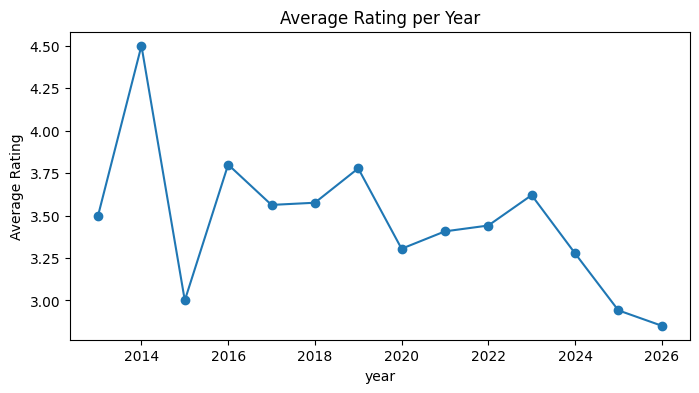

In [9]:
# =========================
# Average Rating per Year (Trend Analysis)
# =========================

# Calculate average rating for each year
avg_rating_year = df.groupby('year')['review_rating'].mean()

# Create figure with specified size
plt.figure(figsize=(8,4))

# Add markers for better readability of yearly changes
avg_rating_year.plot(marker='o')

# Add title and axis label
plt.title("Average Rating per Year")
plt.ylabel("Average Rating")

# Display the plot
plt.show()

### 5. Most Frequent Words
#### Most common words

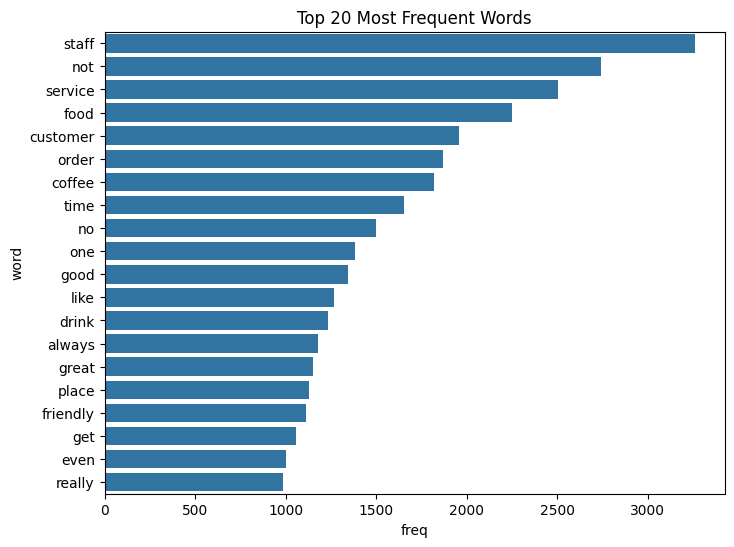

In [10]:
# =========================
# Most Frequent Words (EDA)
# =========================

# Combine all cleaned text into one string and split into individual words
all_words = " ".join(df['clean_text']).split()

# Count frequency of each word
word_freq = Counter(all_words)

# Get top 20 most common words
common_words = word_freq.most_common(20)

# Convert to DataFrame for easier plotting
common_df = pd.DataFrame(common_words, columns=['word', 'freq'])

# Create figure
plt.figure(figsize=(8,6))

# Plot horizontal bar chart of word frequencies
sns.barplot(x='freq', y='word', data=common_df)

# Add title
plt.title("Top 20 Most Frequent Words")

# Display the plot
plt.show()

#### Words by Rating Sentiment

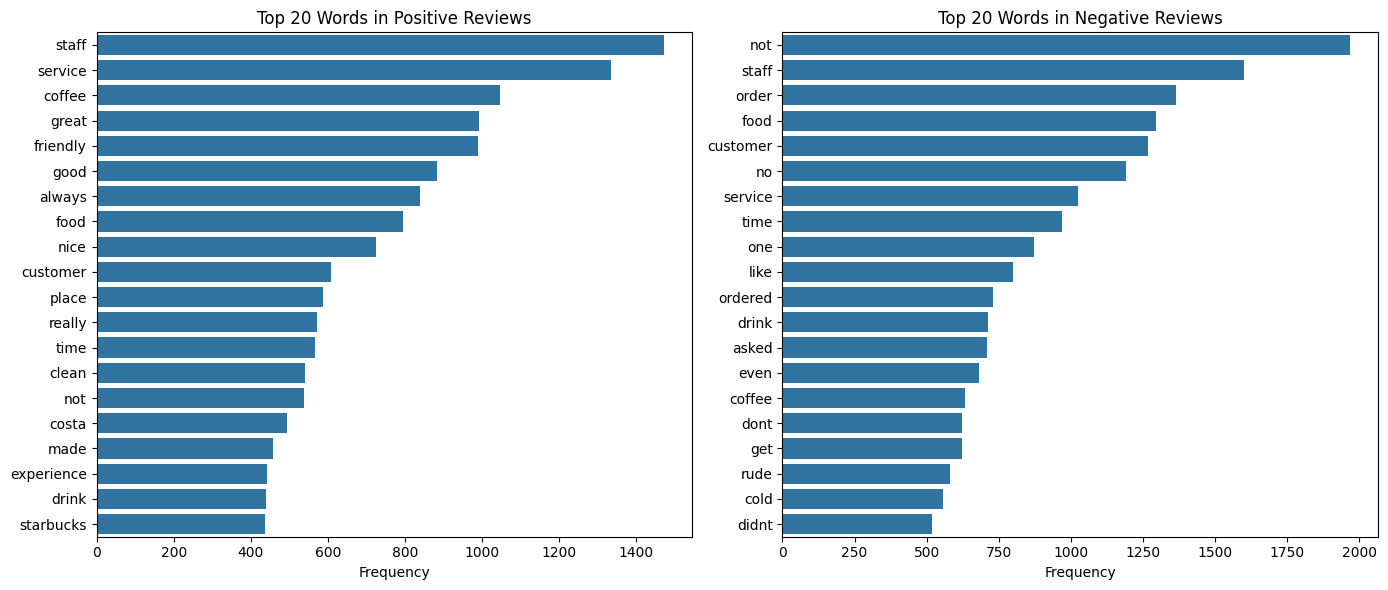

In [11]:
# =========================
# Word Frequency by Sentiment (Positive vs Negative)
# =========================

# Split dataset into positive and negative reviews
# Positive: ratings 4–5, Negative: ratings 1–2
positive = df[df['review_rating'] >= 4]
negative = df[df['review_rating'] <= 2]

# Extract top 20 most frequent words in each group
pos_words = Counter(" ".join(positive['clean_text']).split()).most_common(20)
neg_words = Counter(" ".join(negative['clean_text']).split()).most_common(20)

# Convert to DataFrames for plotting
pos_df = pd.DataFrame(pos_words, columns=['word', 'frequency'])
neg_df = pd.DataFrame(neg_words, columns=['word', 'frequency'])

# Create side-by-side plots for comparison
fig, axes = plt.subplots(1, 2, figsize=(14,6))

# Plot positive word frequencies
sns.barplot(data=pos_df, y='word', x='frequency', ax=axes[0])
axes[0].set_title("Top 20 Words in Positive Reviews")
axes[0].set_xlabel("Frequency")
axes[0].set_ylabel("")

# Plot negative word frequencies
sns.barplot(data=neg_df, y='word', x='frequency', ax=axes[1])
axes[1].set_title("Top 20 Words in Negative Reviews")
axes[1].set_xlabel("Frequency")
axes[1].set_ylabel("")

# Adjust layout for better spacing
plt.tight_layout()

# Display plots
plt.show()

### 6. Correlation Analysis

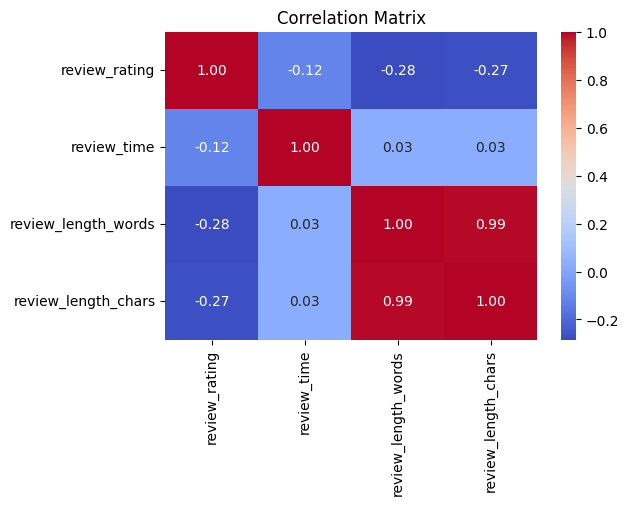

In [12]:
# =========================
# Correlation Analysis (Numeric Features)
# =========================

# Select numeric columns only (e.g., rating, length features, time features)
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Compute correlation matrix (pairwise linear relationships)
corr_matrix = df[numeric_cols].corr()

# Create figure
plt.figure(figsize=(6,4))

# Plot heatmap with correlation values annotated
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")

# Add title
plt.title("Correlation Matrix")

# Display plot
plt.show()

## TF-IDF Feature Engineering

TF-IDF matrix shape: (6113, 5000)
Vocabulary size: 5000


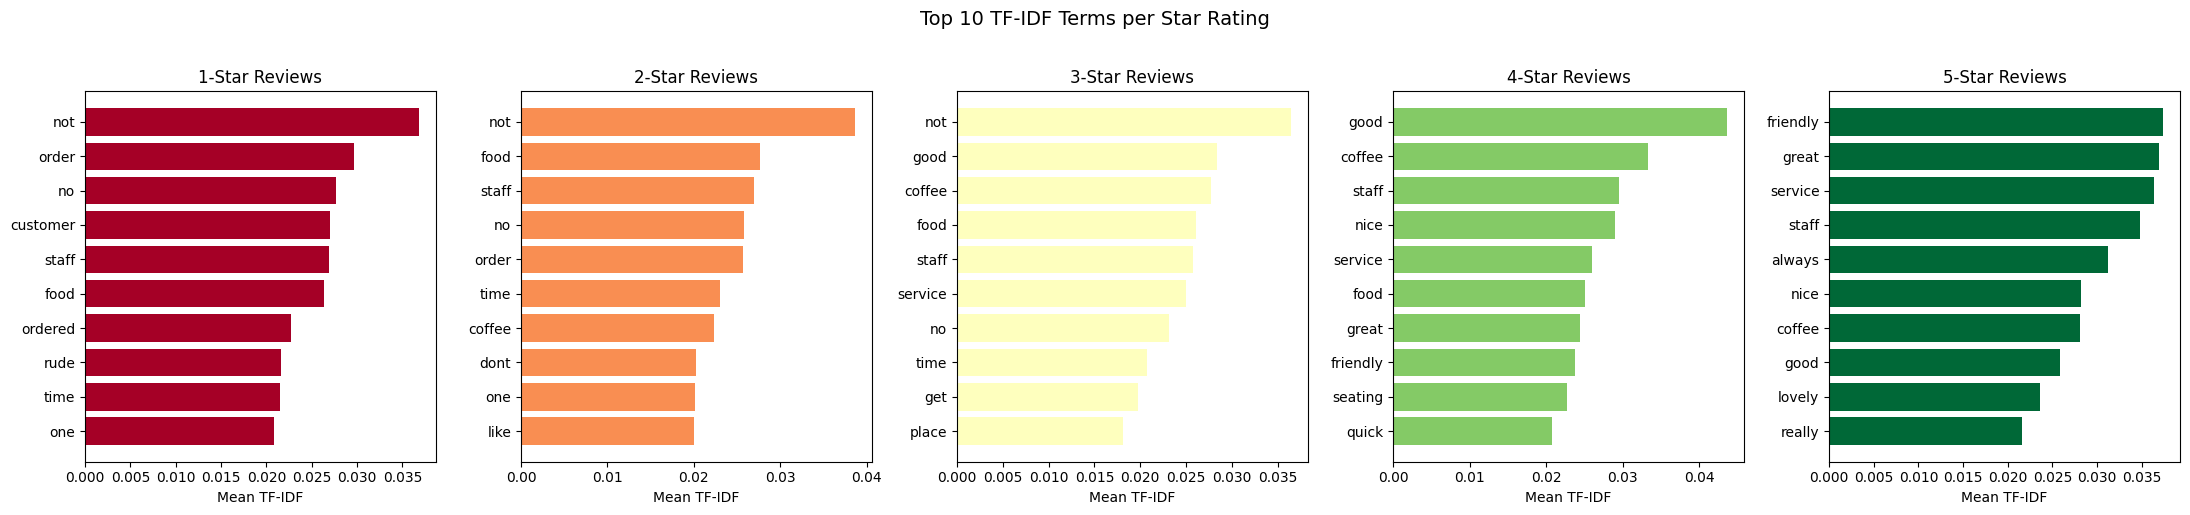

In [13]:
# =========================
# TF-IDF Feature Extraction
# =========================

# TF-IDF feature extraction based on Week 2 (Language Representation)

# Initialize TF-IDF vectorizer
# - max_features: limit vocabulary size (reduce dimensionality)
# - ngram_range: include unigrams and bigrams
# - min_df: ignore very rare terms (noise reduction)
# - sublinear_tf: apply log-scaling to term frequency
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=3,
    sublinear_tf=True
)

# Transform cleaned text into TF-IDF feature matrix
X_tfidf = tfidf.fit_transform(df['clean_text'])

# Target variable (ratings)
y = df['review_rating'].values

# Basic info about feature space
print("TF-IDF matrix shape:", X_tfidf.shape)
print("Vocabulary size:", len(tfidf.vocabulary_))

# Extract feature (word/ngram) names
feature_names = np.array(tfidf.get_feature_names_out())


# =========================
# Top TF-IDF Terms per Rating
# =========================

# Create subplots (one per rating class)
fig, axes = plt.subplots(1, 5, figsize=(22, 5))

# Loop through each rating (1 to 5)
for i, rating in enumerate([1, 2, 3, 4, 5]):

    # Select reviews belonging to the current rating
    mask = y == rating

    # Compute mean TF-IDF score for each term within this rating
    mean_tfidf = np.asarray(X_tfidf[mask].mean(axis=0)).flatten()

    # Get indices of top 10 terms
    top_idx = mean_tfidf.argsort()[-10:][::-1]

    # Plot horizontal bar chart (reverse for better readability)
    axes[i].barh(
        feature_names[top_idx][::-1],
        mean_tfidf[top_idx][::-1],
        color=plt.cm.RdYlGn(i / 4)  # Colour gradient from negative → positive
    )

    # Add subplot title and label
    axes[i].set_title(f"{rating}-Star Reviews")
    axes[i].set_xlabel("Mean TF-IDF")

# Add overall title
plt.suptitle("Top 10 TF-IDF Terms per Star Rating", fontsize=14, y=1.02)

# Adjust layout to prevent overlap
plt.tight_layout()

# Display plots
plt.show()

## RoBERTa-based Sentiment Modelling

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/501M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.pooler.dense.bias       | UNEXPECTED |  | 
roberta.pooler.dense.weight     | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/501M [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

RoBERTa scores shape: (6113, 3)
Columns: [negative, neutral, positive]


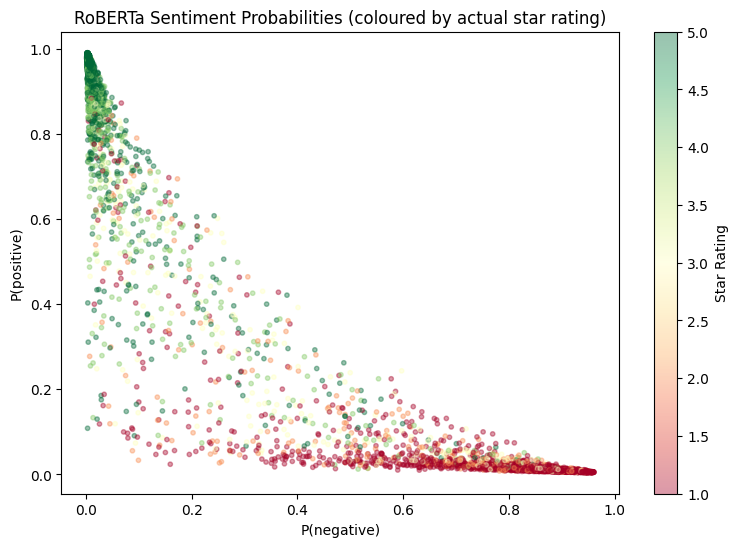

In [14]:
# =========================
# RoBERTa Sentiment Inference
# =========================

# Pre-trained model: cardiffnlp/twitter-roberta-base-sentiment-latest (Loureiro et al., 2022)
# HuggingFace Transformers pipeline based on Week 8 (Transformers & LLMs)

# Load pre-trained RoBERTa model fine-tuned for sentiment analysis
# Outputs probabilities for: negative, neutral, positive
roberta_pipe = pipeline(
    "text-classification",
    model="cardiffnlp/twitter-roberta-base-sentiment-latest",
    top_k=None,
    device=-1   # Use CPU (-1); set to 0 if GPU is available
)

# Function to process texts in batches (improves efficiency)
def get_roberta_scores(texts, batch_size=64):
    all_scores = []

    # Loop through data in batches
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]

        # Run inference (truncate long reviews to 512 tokens)
        outputs = roberta_pipe(batch, truncation=True, max_length=512)

        # Extract probabilities for each sentiment class
        for result in outputs:
            d = {r['label']: r['score'] for r in result}

            # Ensure consistent order: [negative, neutral, positive]
            all_scores.append([
                d.get('negative', 0),
                d.get('neutral', 0),
                d.get('positive', 0)
            ])

    return np.array(all_scores)

# Apply model to all reviews
roberta_scores = get_roberta_scores(df['review_text'].tolist())

# Check output shape (n_samples × 3)
print("RoBERTa scores shape:", roberta_scores.shape)
print("Columns: [negative, neutral, positive]")


# =========================
# Visualisation: Sentiment Probabilities
# =========================

# Scatter plot: negative vs positive probabilities
# Colour represents actual star rating (ground truth)
plt.figure(figsize=(9, 6))

scatter = plt.scatter(
    roberta_scores[:, 0],   # P(negative)
    roberta_scores[:, 2],   # P(positive)
    c=y,                    # True rating labels
    cmap='RdYlGn',          # Red = negative, Green = positive
    alpha=0.4,
    s=10
)

# Add colour bar for rating scale
plt.colorbar(scatter, label='Star Rating')

# Add labels and title
plt.xlabel("P(negative)")
plt.ylabel("P(positive)")
plt.title("RoBERTa Sentiment Probabilities (coloured by actual star rating)")

# Display plot
plt.show()

## Supervised Model Training

In [15]:
# =========================
# Train-Test Split
# =========================

# Define target variable for 5-class classification (ratings 1–5)
# All reviews are retained, so no class is excluded
y_all = df['review_rating'].values

# Create an array of row indices
# This allows the same train-test split to be applied to both TF-IDF and RoBERTa features
idx_all = np.arange(len(y_all))

# Perform stratified split to preserve class proportions in train and test sets
idx_train, idx_test = train_test_split(
    idx_all,
    test_size=0.2,
    random_state=42,
    stratify=y_all
)

# Apply the same split to TF-IDF features
X_tr_tfidf, X_te_tfidf = X_tfidf[idx_train], X_tfidf[idx_test]

# Apply the same split to RoBERTa-derived features
X_tr_rob, X_te_rob = roberta_scores[idx_train], roberta_scores[idx_test]

# Split labels into training and test sets
y_tr, y_te = y_all[idx_train], y_all[idx_test]

# Print sample sizes
print(f"Training samples : {len(y_tr)}")
print(f"Test samples     : {len(y_te)}")

# Display class distribution in the training set
# Useful for checking whether stratification worked correctly
print("\nClass distribution (train):")
for star in [1, 2, 3, 4, 5]:
    print(f"  {star}★ : {sum(y_tr == star)}")

Training samples : 4890
Test samples     : 1223

Class distribution (train):
  1★ : 1845
  2★ : 362
  3★ : 320
  4★ : 491
  5★ : 1872


### Hyperparameter tuning

In [16]:
# =========================
# Hyperparameter Tuning Setup
# =========================

# GridSearchCV: scikit-learn documentation
#   https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html
# LogisticRegression: scikit-learn documentation
#   https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html
# LinearSVC: scikit-learn documentation
#   https://scikit-learn.org/stable/modules/generated/sklearn.svm.LinearSVC.html
# Pedregosa, F. et al. (2011) 'Scikit-learn: Machine Learning in Python', JMLR, 12, pp. 2825-2830.

# Use stratified 5-fold cross-validation to preserve class proportions in each fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define shared hyperparameter grid
# - C controls regularisation strength
# - class_weight='balanced' adjusts for class imbalance
param_grid = {
    "C": [0.1, 1.0, 10.0],
    "class_weight": [None, "balanced"]
}

# =========================
# Logistic Regression + TF-IDF
# =========================

# Perform grid search using macro F1 as the optimisation metric
grid_lr_tfidf = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
)

# Fit model on TF-IDF training data
grid_lr_tfidf.fit(X_tr_tfidf, y_tr)

# Store best hyperparameters
best_C_tfidf = grid_lr_tfidf.best_params_["C"]
best_cw_tfidf = grid_lr_tfidf.best_params_["class_weight"]

# Print best configuration and cross-validated macro F1
print(
    "Best LR+TF-IDF:",
    grid_lr_tfidf.best_params_,
    "→ CV macro F1:",
    f"{grid_lr_tfidf.best_score_:.3f}"
)

# =========================
# Linear SVM + TF-IDF
# =========================

# Initialize LinearSVC model
svc_base = LinearSVC(max_iter=2000, random_state=42)

# Perform separate grid search for SVM
grid_svm_tfidf = GridSearchCV(
    svc_base,
    param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
)

# Fit model on TF-IDF training data
grid_svm_tfidf.fit(X_tr_tfidf, y_tr)

# Store best hyperparameters
best_C_tfidf_svm = grid_svm_tfidf.best_params_["C"]
best_cw_tfidf_svm = grid_svm_tfidf.best_params_["class_weight"]

# Print best configuration and cross-validated macro F1
print(
    "Best SVM+TF-IDF:",
    grid_svm_tfidf.best_params_,
    "→ CV macro F1:",
    f"{grid_svm_tfidf.best_score_:.3f}"
)

# =========================
# Logistic Regression + RoBERTa Features
# =========================

# Perform grid search for Logistic Regression using RoBERTa-derived features
grid_lr_rob = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
)

# Fit model on RoBERTa feature training data
grid_lr_rob.fit(X_tr_rob, y_tr)

# Store best hyperparameters
best_C_rob = grid_lr_rob.best_params_["C"]
best_cw_rob = grid_lr_rob.best_params_["class_weight"]

# Print best configuration and cross-validated macro F1
print(
    "Best LR+RoBERTa:",
    grid_lr_rob.best_params_,
    "→ CV macro F1:",
    f"{grid_lr_rob.best_score_:.3f}"
)

# =========================
# Linear SVM + RoBERTa Features
# =========================

# Initialize separate SVM model for RoBERTa feature tuning
svc_base_rob = LinearSVC(max_iter=2000, random_state=42)

# Perform grid search for SVM using RoBERTa-derived features
grid_svm_rob = GridSearchCV(
    svc_base_rob,
    param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
)

# Fit model on RoBERTa feature training data
grid_svm_rob.fit(X_tr_rob, y_tr)

# Store best hyperparameters
best_C_rob_svm = grid_svm_rob.best_params_["C"]
best_cw_rob_svm = grid_svm_rob.best_params_["class_weight"]

# Print best configuration and cross-validated macro F1
print(
    "Best SVM+RoBERTa:",
    grid_svm_rob.best_params_,
    "→ CV macro F1:",
    f"{grid_svm_rob.best_score_:.3f}"
)

Best LR+TF-IDF: {'C': 0.1, 'class_weight': 'balanced'} → CV macro F1: 0.492
Best SVM+TF-IDF: {'C': 0.1, 'class_weight': 'balanced'} → CV macro F1: 0.472
Best LR+RoBERTa: {'C': 10.0, 'class_weight': 'balanced'} → CV macro F1: 0.468
Best SVM+RoBERTa: {'C': 10.0, 'class_weight': 'balanced'} → CV macro F1: 0.401


In [17]:
# =========================
# Model Training and Evaluation
# =========================

# Use tuned hyperparameters if available.
# If the tuning cell was not run, fall back to default values.
try:
    _ = best_C_tfidf
except NameError:
    best_C_tfidf, best_cw_tfidf = 1.0, None
    best_C_tfidf_svm, best_cw_tfidf_svm = 1.0, None
    best_C_rob, best_cw_rob = 1.0, None
    best_C_rob_svm, best_cw_rob_svm = 1.0, None

# Store macro F1 results for model comparison
results = {}

# Define class labels for the classification report
labels = ['1★', '2★', '3★', '4★', '5★']

# =========================
# 1. Logistic Regression + TF-IDF
# =========================

# Train Logistic Regression on TF-IDF features using tuned parameters
lr_tfidf = LogisticRegression(
    C=best_C_tfidf,
    class_weight=best_cw_tfidf,
    max_iter=1000,
    random_state=42
)
lr_tfidf.fit(X_tr_tfidf, y_tr)

# Generate predictions on the test set
y_pred_lr = lr_tfidf.predict(X_te_tfidf)

# Store macro F1 score
results['LR + TF-IDF'] = f1_score(y_te, y_pred_lr, average='macro')

# Print detailed classification metrics
print("=== Logistic Regression (TF-IDF) ===")
print(classification_report(y_te, y_pred_lr, target_names=labels, digits=3))


# =========================
# 2. LinearSVC + TF-IDF
# =========================

# Train LinearSVC on TF-IDF features using separately tuned parameters
svc = LinearSVC(
    C=best_C_tfidf_svm,
    class_weight=best_cw_tfidf_svm,
    max_iter=2000,
    random_state=42
)
svc.fit(X_tr_tfidf, y_tr)

# Generate predictions on the test set
y_pred_svc = svc.predict(X_te_tfidf)

# Store macro F1 score
results['SVM + TF-IDF'] = f1_score(y_te, y_pred_svc, average='macro')

# Print detailed classification metrics
print("=== LinearSVC (TF-IDF) ===")
print(classification_report(y_te, y_pred_svc, target_names=labels, digits=3))


# =========================
# 3. Logistic Regression + RoBERTa Features
# =========================

# Train Logistic Regression on RoBERTa-derived sentiment features
lr_rob = LogisticRegression(
    C=best_C_rob,
    class_weight=best_cw_rob,
    max_iter=1000,
    random_state=42
)
lr_rob.fit(X_tr_rob, y_tr)

# Generate predictions on the test set
y_pred_rob = lr_rob.predict(X_te_rob)

# Store macro F1 score
results['LR + RoBERTa'] = f1_score(y_te, y_pred_rob, average='macro')

# Print detailed classification metrics
print("=== Logistic Regression (RoBERTa) ===")
print(classification_report(y_te, y_pred_rob, target_names=labels, digits=3))


# =========================
# 4. LinearSVC + RoBERTa
# =========================

# Train LinearSVC on RoBERTa-derived sentiment features
svc_rob = LinearSVC(
    C=best_C_rob_svm,
    class_weight=best_cw_rob_svm,
    max_iter=2000,
    random_state=42
)
svc_rob.fit(X_tr_rob, y_tr)

# Generate predictions on the test set
y_pred_svc_rob = svc_rob.predict(X_te_rob)

# Store macro F1 score
results['SVM + RoBERTa'] = f1_score(y_te, y_pred_svc_rob, average='macro')

# Print detailed classification metrics
print("=== LinearSVC (RoBERTa) ===")
print(classification_report(y_te, y_pred_svc_rob, target_names=labels, digits=3))

=== Logistic Regression (TF-IDF) ===
              precision    recall  f1-score   support

          1★      0.799     0.835     0.817       462
          2★      0.153     0.167     0.160        90
          3★      0.203     0.175     0.188        80
          4★      0.351     0.480     0.405       123
          5★      0.877     0.759     0.813       468

    accuracy                          0.678      1223
   macro avg      0.477     0.483     0.477      1223
weighted avg      0.697     0.678     0.685      1223

=== LinearSVC (TF-IDF) ===
              precision    recall  f1-score   support

          1★      0.782     0.957     0.861       462
          2★      0.200     0.044     0.073        90
          3★      0.292     0.175     0.219        80
          4★      0.407     0.374     0.390       123
          5★      0.832     0.848     0.840       468

    accuracy                          0.738      1223
   macro avg      0.503     0.480     0.476      1223
weighted avg 

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Model Comparison and Error Analysis

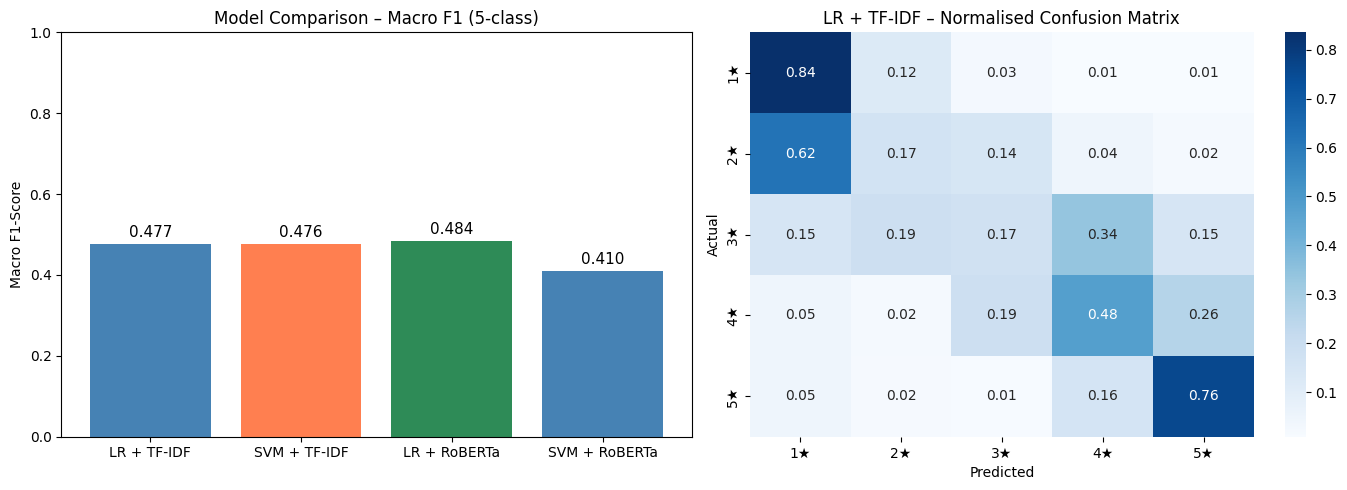

Mismatch counts:
 mismatch
Aligned       5942
Overrated      100
Underrated      71
Name: count, dtype: int64

Overall mismatch rate: 2.8%


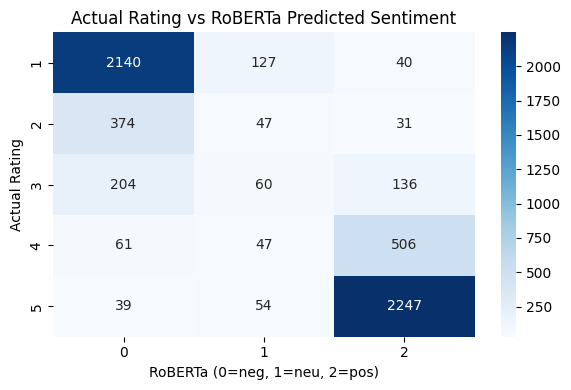

In [18]:
# =========================
# Model Comparison and Error Analysis
# =========================

# Create side-by-side plots:
# (1) Macro F1 comparison across models
# (2) Normalised confusion matrix for the selected best TF-IDF model
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Extract model names and macro F1 scores from results dictionary
model_names = list(results.keys())
f1_vals = list(results.values())

# Plot bar chart of macro F1 scores
bars = axes[0].bar(model_names, f1_vals, color=['steelblue', 'coral', 'seagreen'])

# Format chart
axes[0].set_ylim(0, 1.0)
axes[0].set_ylabel("Macro F1-Score")
axes[0].set_title("Model Comparison – Macro F1 (5-class)")

# Add score labels above each bar
for bar, score in zip(bars, f1_vals):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"{score:.3f}",
        ha='center',
        va='bottom',
        fontsize=11
    )

# =========================
# Confusion Matrix for Best TF-IDF Model
# =========================

# Compute row-normalised confusion matrix
# This shows, for each true class, how predictions are distributed
cm = confusion_matrix(
    y_te,
    y_pred_lr,
    labels=[1, 2, 3, 4, 5],
    normalize='true'
)

# Plot confusion matrix heatmap
sns.heatmap(
    cm,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    ax=axes[1],
    xticklabels=['1★', '2★', '3★', '4★', '5★'],
    yticklabels=['1★', '2★', '3★', '4★', '5★']
)

# Add title and labels
axes[1].set_title("LR + TF-IDF – Normalised Confusion Matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

# Adjust layout and display figure
plt.tight_layout()
plt.show()


# =========================
# Mismatch Detection using Zero-Shot RoBERTa
# =========================

# Implemented by Team 12

# Convert RoBERTa sentiment probabilities into sentiment class predictions
# 0 = negative, 1 = neutral, 2 = positive
roberta_pred = np.argmax(roberta_scores, axis=1)

# Store RoBERTa outputs in the DataFrame for inspection
df['roberta_neg'] = roberta_scores[:, 0]
df['roberta_pos'] = roberta_scores[:, 2]
df['roberta_pred'] = roberta_pred

# Initialise all reviews as aligned
df['mismatch'] = 'Aligned'

# Flag possible rating-text mismatches:
# - Overrated: high star rating but negative sentiment
# - Underrated: low star rating but positive sentiment
df.loc[(df['review_rating'] >= 4) & (df['roberta_pred'] == 0), 'mismatch'] = 'Overrated'
df.loc[(df['review_rating'] <= 2) & (df['roberta_pred'] == 2), 'mismatch'] = 'Underrated'

# Summarise mismatch counts
mismatch_counts = df['mismatch'].value_counts()
print("Mismatch counts:\n", mismatch_counts)

# Compute overall mismatch rate
print(f"\nOverall mismatch rate: {(df['mismatch'] != 'Aligned').mean():.1%}")

# =========================
# Crosstab: Actual Rating vs RoBERTa Sentiment
# =========================

# Create contingency table between star ratings and RoBERTa sentiment predictions
cross = pd.crosstab(
    df['review_rating'],
    df['roberta_pred'],
    rownames=['Actual Rating'],
    colnames=['RoBERTa (0=neg, 1=neu, 2=pos)']
)

# Plot heatmap of crosstab counts
plt.figure(figsize=(6, 4))
sns.heatmap(cross, annot=True, fmt='d', cmap='Blues')

# Add title and display
plt.title("Actual Rating vs RoBERTa Predicted Sentiment")
plt.tight_layout()
plt.show()

### Refined mismatch definition (probability thresholds)

The simple rule above flags **Overrated** when rating ≥ 4 and RoBERTa predicts negative, and **Underrated** when rating ≤ 2 and RoBERTa predicts positive. To reduce noise, a *refined* rule using probability thresholds is defined(e.g. require P(negative) > τ for Overrated).

In [19]:
# =========================
# Refined Mismatch Detection (Threshold-based)
# =========================

# Define probability thresholds (tau) to test sensitivity
# Higher tau = stricter definition of mismatch
tau_values = [0.5, 0.6, 0.7]

# Store results for each threshold
refined_rows = []

# Loop through each threshold value
for tau in tau_values:

    # Initialise all reviews as 'Aligned'
    m = 'Aligned'
    df['mismatch_refined'] = m

    # Define refined mismatch conditions:
    # - Overrated: high rating but strong negative sentiment
    df.loc[
        (df['review_rating'] >= 4) & (df['roberta_neg'] > tau),
        'mismatch_refined'
    ] = 'Overrated'

    # - Underrated: low rating but strong positive sentiment
    df.loc[
        (df['review_rating'] <= 2) & (df['roberta_pos'] > tau),
        'mismatch_refined'
    ] = 'Underrated'

    # Calculate percentage distribution of mismatch categories
    counts = df['mismatch_refined'].value_counts(normalize=True) * 100

    # Store results for this tau
    refined_rows.append({
        'tau': tau,
        'aligned_pct': counts.get('Aligned', 0),
        'overrated_pct': counts.get('Overrated', 0),
        'underrated_pct': counts.get('Underrated', 0),
    })

# Convert results into DataFrame for comparison
refined_df = pd.DataFrame(refined_rows)

# Print sensitivity analysis table
print("Mismatch rate sensitivity to τ:")
print(refined_df.to_string(index=False))

Mismatch rate sensitivity to τ:
 tau  aligned_pct  overrated_pct  underrated_pct
 0.5    97.758875       1.292328        0.948798
 0.6    98.265991       0.916080        0.817929
 0.7    98.740389       0.768853        0.490757


In [20]:
# =========================
# Qualitative Inspection of Mismatched Reviews
# =========================

# This section prints example reviews where:
# - The star rating and text sentiment disagree
# - Helps understand model behaviour and potential data noise

# -------------------------
# Overrated Reviews
# -------------------------
# High star rating (≥4) but RoBERTa predicts negative sentiment

print("=" * 70)
print("OVERRATED – High star rating but RoBERTa predicts NEGATIVE")
print("=" * 70)

# Select top 5 most strongly negative (highest P(negative))
overrated = df[df['mismatch'] == 'Overrated'].nlargest(5, 'roberta_neg')

# Print examples
for _, row in overrated.iterrows():
    print(f"\n[{int(row['review_rating'])} stars | P(neg)={row['roberta_neg']:.2f} | P(pos)={row['roberta_pos']:.2f}]")

    # Show first 300 characters of review for readability
    print(row['review_text'][:300])
    print("-" * 70)


# -------------------------
# Underrated Reviews
# -------------------------
# Low star rating (≤2) but RoBERTa predicts positive sentiment

print("\n" + "=" * 70)
print("UNDERRATED – Low star rating but RoBERTa predicts POSITIVE")
print("=" * 70)

# Select top 5 most strongly positive (highest P(positive))
underrated = df[df['mismatch'] == 'Underrated'].nlargest(5, 'roberta_pos')

# Print examples
for _, row in underrated.iterrows():
    print(f"\n[{int(row['review_rating'])} stars | P(neg)={row['roberta_neg']:.2f} | P(pos)={row['roberta_pos']:.2f}]")

    # Show first 300 characters of review for readability
    print(row['review_text'][:300])
    print("-" * 70)

OVERRATED – High star rating but RoBERTa predicts NEGATIVE

[4 stars | P(neg)=0.95 | P(pos)=0.01]
A standard Greggs. Their new Spicy Veg Festive pasty tasted really bad.
----------------------------------------------------------------------

[5 stars | P(neg)=0.93 | P(pos)=0.01]
Same as ever. Slow service, barely warm food and half the restaurant closed off for cleaning with no one actually cleaning, so seats at a premium, even though it was only 6pm and really busy. Loads of drive thru orders incorrect and returned.
----------------------------------------------------------------------

[4 stars | P(neg)=0.89 | P(pos)=0.01]
Take out only. Very expensive rent I’m sure so they have no seating. Very disappointing but then most people here getting on trains so we understand.
----------------------------------------------------------------------

[4 stars | P(neg)=0.89 | P(pos)=0.01]
Very kindly service and emoloyers. But,  , unfotunatelly, many  customers  are not polite.

food and glasse

### Error and lexical analysis

In [21]:
# =========================
# Keyword Analysis for Mismatched Reviews
# =========================

# Combine all cleaned text from 'Overrated' reviews into one string
# (High rating but negative sentiment)
overrated_text = ' '.join(
    df.loc[df['mismatch'] == 'Overrated', 'clean_text']
    .dropna()
    .astype(str)
)

# Combine all cleaned text from 'Underrated' reviews into one string
# (Low rating but positive sentiment)
underrated_text = ' '.join(
    df.loc[df['mismatch'] == 'Underrated', 'clean_text']
    .dropna()
    .astype(str)
)

# Count most frequent words in each group
overrated_words = Counter(overrated_text.split()).most_common(15)
underrated_words = Counter(underrated_text.split()).most_common(15)

# Print top terms (words only, ignoring frequencies)
print("Top 15 terms in Overrated reviews (high star, RoBERTa negative):")
print([w for w, _ in overrated_words])

print("\nTop 15 terms in Underrated reviews (low star, RoBERTa positive):")
print([w for w, _ in underrated_words])

Top 15 terms in Overrated reviews (high star, RoBERTa negative):
['not', 'food', 'staff', 'service', 'good', 'one', 'order', 'dont', 'time', 'coffee', 'get', 'really', 'like', 'customer', 'no']

Top 15 terms in Underrated reviews (low star, RoBERTa positive):
['not', 'food', 'customer', 'one', 'time', 'staff', 'greggs', 'like', 'no', 'drink', 'good', 'service', 'order', 'always', 'coffee']


## External validation on Yelp restaurant reviews

In [22]:
# =========================
# External Validation on Yelp Dataset
# =========================

# Yelp Restaurant Reviews dataset by Faruk Alam
# Source: https://www.kaggle.com/datasets/farukalam/yelp-restaurant-reviews

# Load Yelp dataset and align column names with the Google reviews dataset
yelp = pd.read_csv("Yelp Restaurant Reviews.csv")
yelp = yelp.rename(columns={"Review Text": "review_text", "Rating": "review_rating"})

# Ensure ratings are stored as integers
yelp['review_rating'] = yelp['review_rating'].astype(int)

# Apply the same text preprocessing pipeline used for Google reviews
# This ensures consistency between training and external evaluation data
yelp['clean_text'] = yelp['review_text'].apply(preprocess_text)

# =========================
# Feature Construction
# =========================

# Transform Yelp reviews using the existing TF-IDF vectoriser fitted on Google reviews
# Important: use transform(), not fit_transform(), to preserve the original vocabulary
X_yelp_tfidf = tfidf.transform(yelp['clean_text'])

# Define Yelp target labels
y_yelp = yelp['review_rating'].values

# Generate RoBERTa sentiment features for Yelp reviews using the existing pipeline
X_yelp_rob = get_roberta_scores(yelp['review_text'].tolist())

# Dictionary to store external validation results
results_yelp = {}

# =========================
# 1. Logistic Regression + TF-IDF
# =========================

print("=== Logistic Regression + TF-IDF on Yelp ===")

# Predict Yelp ratings using the model trained on Google reviews
y_yelp_lr = lr_tfidf.predict(X_yelp_tfidf)

# Print detailed classification metrics
print(classification_report(y_yelp, y_yelp_lr, target_names=labels, digits=3))

# Store macro F1 score
results_yelp['LR + TF-IDF (Yelp)'] = f1_score(y_yelp, y_yelp_lr, average='macro')

# =========================
# 2. LinearSVC + TF-IDF
# =========================

print("\n=== LinearSVC + TF-IDF on Yelp ===")

# Predict Yelp ratings using the SVM model trained on Google reviews
y_yelp_svc = svc.predict(X_yelp_tfidf)

# Print detailed classification metrics
print(classification_report(y_yelp, y_yelp_svc, target_names=labels, digits=3))

# Store macro F1 score
results_yelp['SVM + TF-IDF (Yelp)'] = f1_score(y_yelp, y_yelp_svc, average='macro')

# =========================
# 3. Logistic Regression + RoBERTa
# =========================

print("\n=== Logistic Regression + RoBERTa on Yelp ===")

# Predict Yelp ratings using RoBERTa-derived features
y_yelp_lr_rob = lr_rob.predict(X_yelp_rob)

# Print detailed classification metrics
print(classification_report(y_yelp, y_yelp_lr_rob, target_names=labels, digits=3))

# Store macro F1 score
results_yelp['LR + RoBERTa (Yelp)'] = f1_score(y_yelp, y_yelp_lr_rob, average='macro')

# =========================
# 4. LinearSVC + RoBERTa
# =========================

print("\n=== LinearSVC + RoBERTa on Yelp ===")

# Predict Yelp ratings using SVM with RoBERTa-derived features
y_yelp_svc_rob = svc_rob.predict(X_yelp_rob)

# Print detailed classification metrics
print(classification_report(y_yelp, y_yelp_svc_rob, target_names=labels, digits=3))

# Store macro F1 score
results_yelp['SVM + RoBERTa (Yelp)'] = f1_score(y_yelp, y_yelp_svc_rob, average='macro')

# =========================
# Summary of External Validation Results
# =========================

print("\nMacro F1 on Yelp (external dataset):")
for name, f1 in results_yelp.items():
    print(f"{name}: {f1:.3f}")

=== Logistic Regression + TF-IDF on Yelp ===
              precision    recall  f1-score   support

          1★      0.270     0.615     0.375      1217
          2★      0.192     0.280     0.228      1280
          3★      0.212     0.395     0.276      2069
          4★      0.372     0.349     0.360      4447
          5★      0.823     0.547     0.657     10883

    accuracy                          0.474     19896
   macro avg      0.374     0.437     0.379     19896
weighted avg      0.584     0.474     0.506     19896


=== LinearSVC + TF-IDF on Yelp ===
              precision    recall  f1-score   support

          1★      0.255     0.804     0.387      1217
          2★      0.231     0.116     0.155      1280
          3★      0.284     0.261     0.272      2069
          4★      0.399     0.277     0.327      4447
          5★      0.766     0.735     0.750     10883

    accuracy                          0.547     19896
   macro avg      0.387     0.439     0.378     19

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [23]:
# =========================
# Summary: Google vs Yelp Performance Comparison
# =========================

print("=== Macro F1 comparison: Google vs Yelp ===")

# Results on original Google Maps test split
# (In-sample evaluation using held-out test data)
print("\nGoogle test split (original dataset):")
for name, f1 in results.items():
    print(f"{name}: {f1:.3f}")

# Results on external Yelp dataset
# (Out-of-sample evaluation to assess generalisation)
print("\nYelp external dataset:")
for name, f1 in results_yelp.items():
    print(f"{name}: {f1:.3f}")

=== Macro F1 comparison: Google vs Yelp ===

Google test split (original dataset):
LR + TF-IDF: 0.477
SVM + TF-IDF: 0.476
LR + RoBERTa: 0.484
SVM + RoBERTa: 0.410

Yelp external dataset:
LR + TF-IDF (Yelp): 0.379
SVM + TF-IDF (Yelp): 0.378
LR + RoBERTa (Yelp): 0.420
SVM + RoBERTa (Yelp): 0.317
